In [1]:
from torchsummary import summary
import reinforcement
import models
import gymnasium as gym
import numpy as np
import torch
import ale_py
import time
import utils

In [2]:
env = gym.make("BipedalWalker-v3", hardcore = 1)
s, _ = env.reset()

env.states = env.observation_space.shape[0]*4
env.actions = env.action_space.shape[0]

actor = models.MLP(env.states, env.actions, softmax=False, tanh=True, lr = 1e-4, hidden_dims = [500, 400, 300, 200])
critic = models.TD3_critic((env.states+env.actions), 1, softmax=False, lr = 1e-3, hidden_dims = [500, 400, 300, 200])

device = "cuda"
actor.to(device)
critic.to(device)

rewards, steps, acc_steps, actor_loss, critic_loss, td_errors = reinforcement.train_tdddpg(env, actor, critic,
                gamma = 0.99, nframes = 4, buffer_size = 1000000, episodes = 5000, verbose=1, checkpoint=50, alpha = 0.6, beta = 0.4)
#rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, episodes = 100, verbose=1, checkpoint=999, BATCH_SIZE=0)


c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 0 finished with reward -117.54545593261719 in 65 steps and 0.020209 time, Total steps: 66
Actor loss: 0, Critic loss: 0, Total steps: 66
Episode 1 finished with reward -174.6127567144839 in 1175 steps and 5.270286 time, Total steps: 1242
Actor loss: 0.5873762363344739, Critic loss: 5.1767205166407235, Total steps: 1242
Episode 2 finished with reward -113.51609971621656 in 132 steps and 2.039267 time, Total steps: 1375
Actor loss: 0.7773259984913157, Critic loss: 15.121826200556935, Total steps: 1375
Interrupting...
Training finished after 3 episodes and 11.130094 seconds, averaging 3.710031 seconds per episode


-18.68676239550262 913.3883142298015


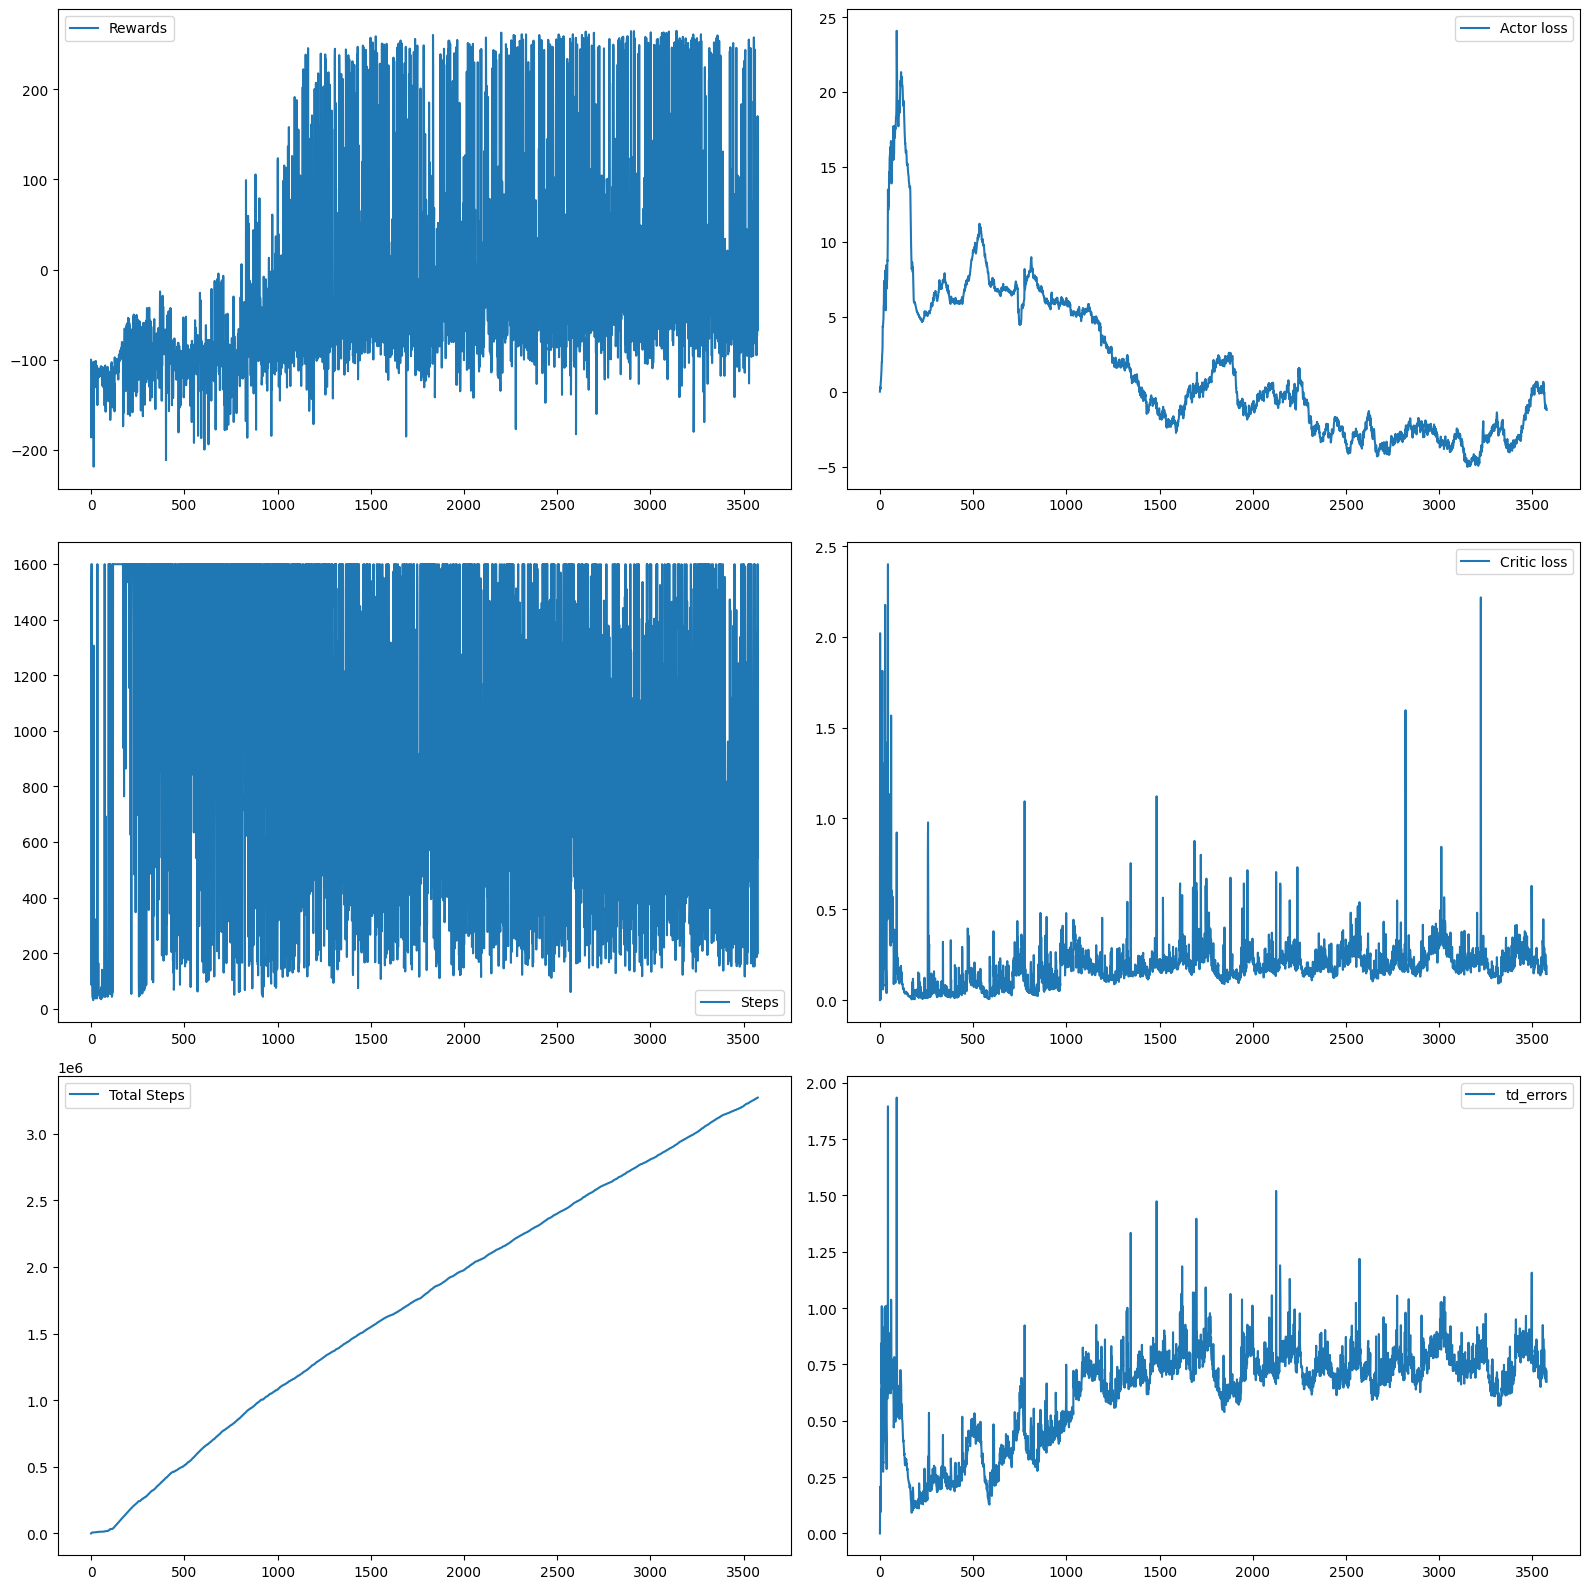

In [ ]:
import matplotlib.pyplot as plt
## Plot the rewards, steps, and errors
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize=(16, 16))
ax[0,0].plot(rewards, label='Rewards')
ax[1,0].plot(steps, label='Steps')
ax[2,0].plot(acc_steps, label='Total Steps')  

ax[0,1].plot(actor_loss, label='Actor loss')  
ax[1,1].plot(critic_loss, label='Critic loss')  
ax[2,1].plot(td_errors, label='td_errors')  

ax[0,0].legend()
ax[1,0].legend()
ax[2,0].legend()

ax[0,1].legend()
ax[1,1].legend()
ax[2,1].legend()

print(np.mean(rewards), np.mean(steps))

plt.tight_layout()
plt.show()

In [ ]:
env = gym.make("BipedalWalker-v3", hardcore = 1)
s, _ = env.reset()

env.states = env.observation_space.shape[0]*4
env.actions = env.action_space.shape[0]

actor = models.MLP(env.states, env.actions, softmax=False, tanh=True, lr = 1e-4, hidden_dims = [500, 400, 300, 200])
critic = models.TD3_critic((env.states+env.actions), 1, softmax=False, lr = 1e-3, hidden_dims = [500, 400, 300, 200])

device = "cuda"
actor.to(device)
critic.to(device)

rewards, steps, acc_steps, actor_loss, critic_loss, td_errors = reinforcement.train_tdddpg(env, actor, critic,
                gamma = 0.99, nframes = 4, buffer_size = 1000000, episodes = 5000, verbose=1, checkpoint=50, alpha = 0.6, beta = 0.4)
#rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, episodes = 100, verbose=1, checkpoint=999, BATCH_SIZE=0)


Episode 0 finished with reward -100.24411010742188 in 88 steps and 0.031068 time, Total steps: 89
Actor loss: 0, Critic loss: 0, Total steps: 89
Episode 1 finished with reward -186.36553843082186 in 1526 steps and 8.696362 time, Total steps: 1616
Actor loss: 0.3000323155780728, Critic loss: 2.0201444270062057, Total steps: 1616
Episode 2 finished with reward -157.40497747319057 in 1599 steps and 21.874176 time, Total steps: 3216
Actor loss: 0.2223682221287163, Critic loss: 0.5796019526458985, Total steps: 3216
Episode 3 finished with reward -141.8891886485908 in 1599 steps and 22.237053 time, Total steps: 4816
Actor loss: 0.16566161785274744, Critic loss: 0.0035466005218222564, Total steps: 4816
Episode 4 finished with reward -153.87570975488077 in 1599 steps and 22.260867 time, Total steps: 6416
Actor loss: 0.5438266973407008, Critic loss: 0.0031927798570086452, Total steps: 6416
Episode 5 finished with reward -123.5065415072682 in 739 steps and 10.296571 time, Total steps: 7156
Actor

In [ ]:
import importlib
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\hss19\\Documents\\GitHub\\ml-2025\\mlc\\reinforcement\\utils.py'>

In [ ]:
env = gym.make("BipedalWalker-v3", hardcore = 1, render_mode = "rgb_array")

actor.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/2025-06-28_11;24;45/models/actor_ep800.pth"))
critic.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/2025-06-28_11;24;45/models/critic_ep800.pth"))

#video_folder = "agents/ddpg/BipedalWalker-v3/2025-06-24_16;52;53/videos"
video_folder = "temp/"
utils.record_model(env, actor, video_folder, "ep1000", nframes = 4)

Episode finished. Total reward: -48.876380920410156
